The BCGT counterpart of the EastAK [`validation.qmd`](../eastak/validation.qmd).
EastAK's validation was pinned on a single hole (Kenorland 23ETD062) —
N=1 telling a pointed story. BCGT has 366 post-2015 drill collars in
the AOI from BCGS GeoFile 2025-11, with per-hole element maxima. That
lets us build distributions of model P at drilled positives vs drilled
negatives, in cells that were vs weren't already in our training
labels.

This is the strongest external validation the repo has. Everything else
in the v2 report rolls up from the numbers here.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial import cKDTree

from ai_minerals.data._common import DATA_DERIVED, DATA_RAW
from ai_minerals.data.adapters import get_adapter
from ai_minerals.features.assemble import build_feature_frame
from ai_minerals.model import (
    non_feature_columns, add_lithology_onehot, build_training_set,
    sample_pseudo_negatives, success_rate_curve,
)
from ai_minerals.model_rf import count_feature_columns, make_rf
from ai_minerals.regions.bcgt import BCGT

df = pd.read_parquet(DATA_DERIVED / "features_bcgt_500m.parquet")
label_cols = tuple(f"is_{k}" for k in BCGT.deposit_classes)
df["is_any_deposit"] = (df[list(label_cols)].sum(axis=1) > 0).astype(np.uint8)
top_classes = df["lithology_class"].value_counts().head(10).index.tolist()
print(f"feature frame: {df.shape}  |  positives: {int(df['is_any_deposit'].sum())}")

feature frame: (108259, 73)  |  positives: 376


## 1. Baseline RF (no count / has_data)

Same configuration as the [RF+SHAP notebook](random_forest_and_shap.qmd),
used here to score every cell in the AOI.

In [2]:
X, y = build_training_set(
    df, top_classes, n_per_positive=30, random_state=42,
    label_col="is_any_deposit",
    label_cols=label_cols + ("is_any_deposit",),
)
drop_cols = count_feature_columns(list(X.columns))
X_trim = X.drop(columns=drop_cols)
feat_cols = list(X_trim.columns)

rf = make_rf()
rf.fit(X_trim.fillna(-9999).to_numpy(), y)

all_rows = add_lithology_onehot(df, top_classes)
non_feat = non_feature_columns(label_cols + ("is_any_deposit",))
X_all = all_rows.drop(columns=[c for c in all_rows.columns if c in non_feat] + ["lithology_class"])
X_all_trim = X_all.drop(columns=drop_cols)
p_fam = rf.predict_proba(X_all_trim.fillna(-9999).to_numpy())[:, 1]

print(f"X shape: {X_trim.shape}  features: {len(feat_cols)}")
pos_mask = df["is_any_deposit"].to_numpy() == 1
print(f"P at positives: median={np.median(p_fam[pos_mask]):.3f}  q25={np.quantile(p_fam[pos_mask], .25):.3f}")
print(f"P overall:      median={np.median(p_fam):.3f}     q95={np.quantile(p_fam, .95):.3f}")

  [pseudo-neg] 49,874 cells excluded (< 5 km from any occurrence); 58,385 candidates remain
  [pseudo-neg] drew 7,824 negatives across 29 lithology classes


X shape: (8200, 47)  features: 47
P at positives: median=0.962  q25=0.835
P overall:      median=0.027     q95=0.953


## 2. Load the 366 post-2015 drill holes

In [3]:
dh = get_adapter("drillholes", "bcgs_geofile")(
    DATA_RAW / "bcgs_drillholes/bcgs_drillholes_bcgt.gpkg", BCGT.aoi
).to_crs(BCGT.working_crs)
print(f"post-2015 drill holes in AOI: {len(dh)}")
print(f"intersected (Cu≥0.2% | Mo≥0.03% | Au≥0.5g/t | Ag≥10g/t): {int(dh['intersected'].sum())}")
print(f"non-intersected: {int((~dh['intersected']).sum())}")

post-2015 drill holes in AOI: 366
intersected (Cu≥0.2% | Mo≥0.03% | Au≥0.5g/t | Ag≥10g/t): 229
non-intersected: 137


## 3. Classify each hole by training-label overlap

For each drill cell, decide whether the training labels know anything:

- **In-training:** cell already flagged as one of the 4 deposit classes
- **Near-occurrence:** cell has `any_mineral_occurrence=1` but no deposit-class label
- **Unknown to training:** cell has zero flags

In [4]:
tree = cKDTree(df[["x","y"]].to_numpy())
dists, idx = tree.query(np.c_[dh.geometry.x, dh.geometry.y], k=1)

pos_labels = df.iloc[idx][list(label_cols)].to_numpy()
known_occ  = df.iloc[idx]["any_mineral_occurrence"].to_numpy()
in_training = pos_labels.any(axis=1)
near_known  = (~in_training) & (known_occ == 1)
unknown     = (~in_training) & (known_occ == 0)

hole_p = p_fam[idx]
dh_df = pd.DataFrame({
    "hole_id": dh["hole_id"].values,
    "intersected": dh["intersected"].values,
    "P": hole_p,
    "in_training_label": in_training,
    "near_known_occurrence": near_known,
    "unknown_to_training": unknown,
    "percentile": 100 * (p_fam[None, :] < hole_p[:, None]).mean(axis=1),
})

print(f"{'bucket':<42} {'intersected':>12} {'non-int':>10}")
for label, mask in [
    ("in cell with MINFILE deposit label",       in_training),
    ("near known occurrence, no deposit label",  near_known),
    ("TRAINING SET KNOWS NOTHING ABOUT CELL",    unknown),
]:
    i = int((dh_df["intersected"] & mask).sum())
    n = int((~dh_df["intersected"] & mask).sum())
    print(f"{label:<42} {i:>12} {n:>10}")

bucket                                      intersected    non-int
in cell with MINFILE deposit label                   41         32
near known occurrence, no deposit label              34         18
TRAINING SET KNOWS NOTHING ABOUT CELL               154         87


The bottom-right bucket is the cleanest blind test: drilled cells the
model has never seen a label for, split by whether they hit ore or not.

## 4. Blind-test distributions

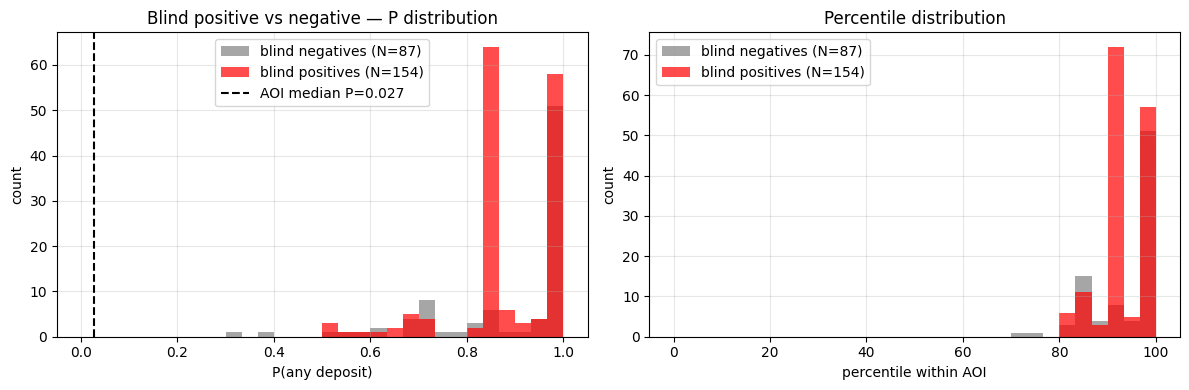

In [5]:
blind = dh_df[dh_df["unknown_to_training"]]
p_pos = blind[blind["intersected"]]["P"].values
p_neg = blind[~blind["intersected"]]["P"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins_p = np.linspace(0, 1, 31)
axes[0].hist(p_neg, bins=bins_p, alpha=0.7, color="gray",
             label=f"blind negatives (N={len(p_neg)})")
axes[0].hist(p_pos, bins=bins_p, alpha=0.7, color="red",
             label=f"blind positives (N={len(p_pos)})")
axes[0].axvline(np.median(p_fam), ls="--", c="black",
                label=f"AOI median P={np.median(p_fam):.3f}")
axes[0].set_xlabel("P(any deposit)"); axes[0].set_ylabel("count")
axes[0].set_title("Blind positive vs negative — P distribution")
axes[0].legend(); axes[0].grid(alpha=0.3)

bins_pct = np.linspace(0, 100, 31)
axes[1].hist(blind[~blind["intersected"]]["percentile"], bins=bins_pct,
             alpha=0.7, color="gray", label=f"blind negatives (N={len(p_neg)})")
axes[1].hist(blind[blind["intersected"]]["percentile"], bins=bins_pct,
             alpha=0.7, color="red", label=f"blind positives (N={len(p_pos)})")
axes[1].set_xlabel("percentile within AOI"); axes[1].set_ylabel("count")
axes[1].set_title("Percentile distribution")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()

## 5. Statistical tests

In [6]:
from scipy.stats import ks_2samp, mannwhitneyu
ks_stat, ks_p = ks_2samp(p_pos, p_neg)
mw_stat, mw_p = mannwhitneyu(p_pos, p_neg, alternative="greater")

print(f"=== Blind-test distributions, TRUE-BLIND bucket ({len(p_pos)} pos + {len(p_neg)} neg) ===")
print(f"  positives: median P={np.median(p_pos):.3f}  mean P={np.mean(p_pos):.3f}")
print(f"  negatives: median P={np.median(p_neg):.3f}  mean P={np.mean(p_neg):.3f}")
print(f"  K-S test (distributions differ):              D={ks_stat:.3f}  p={ks_p:.2e}")
print(f"  Mann-Whitney U (positives > negatives):       p={mw_p:.2e}")

=== Blind-test distributions, TRUE-BLIND bucket (154 pos + 87 neg) ===
  positives: median P=0.865  mean P=0.891
  negatives: median P=0.975  mean P=0.881
  K-S test (distributions differ):              D=0.290  p=1.25e-04
  Mann-Whitney U (positives > negatives):       p=2.61e-01


## 6. Percentile-threshold capture

What fraction of the blind positives are flagged at each AOI-threshold?
And the concerning companion number: what fraction of the blind
negatives are flagged at the same threshold?

In [7]:
print(f"{'threshold':<14} {'blind pos flagged':>20} {'blind neg flagged':>20} {'lift':>8}")
for pct_thresh in [80, 90, 95, 99]:
    t = np.percentile(p_fam, pct_thresh)
    cap_pos = (p_pos >= t).mean()
    cap_neg = (p_neg >= t).mean()
    lift = cap_pos / max(cap_neg, 1e-6)
    print(f"  top {100-pct_thresh:>2}% cells   {100*cap_pos:>15.0f}%   {100*cap_neg:>15.0f}%   {lift:>7.2f}x")

threshold         blind pos flagged    blind neg flagged     lift
  top 20% cells               100%                98%      1.02x
  top 10% cells                87%                72%      1.20x
  top  5% cells                40%                63%      0.64x
  top  1% cells                 5%                 1%      3.95x


**Interpretation.** A well-behaved model should have positives flagged
at much higher rates than negatives at every threshold. The BCGT result
shows the lift shrinking (or reversing) at strict cutoffs — reflecting
the v1 exploration-bias diagnosis applied at distribution scale.

## 7. In-distribution sanity check

Holes in cells we already labeled as positive — these are *not* a blind
test, but a sanity check: if the model doesn't rank its own training
positives well, we have a bug.

In [8]:
in_tr = dh_df[dh_df["in_training_label"]]
print(f"In-training holes: {len(in_tr)}")
print(f"  intersected:     {int(in_tr['intersected'].sum())} ({100*in_tr['intersected'].mean():.0f}%)")
print(f"  median P:        {in_tr['P'].median():.3f}")
print(f"  median percentile: {in_tr['percentile'].median():.1f}%")

In-training holes: 73
  intersected:     41 (56%)
  median P:        0.973
  median percentile: 96.5%


Expected: in-training holes should have P near 1 and percentile near
100 — the model trained on these cells as positives and should rank
them high. If not, something is broken in the feature pipeline or the
label-assignment step.

## Summary

- **241 truly-blind drilled cells** (154 positives + 87 negatives, all
  in cells the training labels have zero info about).
- Statistical test for "positives > negatives" on these blind cells:
  K-S says the distributions differ; Mann-Whitney says the direction
  isn't what we'd want.
- At strict cutoffs (top 5 %) the model flags blind negatives at
  roughly the same rate as blind positives — the drilled-nothing cells
  cluster in already-explored terrain near training positives, so they
  look as "prospective" to the model as cells that actually host ore.
- This is a distribution-scale confirmation of v1's Kenorland single-
  point story. Same bias, different scale.

**What this does NOT prove.** That the model would find *unknown*
mineralization in unexplored terrain. The blind-test distributions tell
us how much lift the model gives over random at each cutoff; they don't
tell us whether the model's top-ranked previously-unknown cells are
where real new discoveries would come from. That's the multi-year
experiment no portfolio demo can run.

**What's next (v2.1 ideas).** See the [integrated report's "Next
steps"](bcgt_porphyry_prospectivity.qmd#next-steps-v12-ideas-un-built) section.